# Parameters

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd

# ===== CONFIGURAÇÃO DE CAMINHOS =====
current_notebook = Path.cwd()  
project_root = current_notebook.parent.parent 

# Adiciona o diretório raiz ao sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


# Adiciona o diretório Modules ao sys.path
modules_dir = project_root / "Modules"
if str(modules_dir) not in sys.path:
    sys.path.insert(0, str(modules_dir))

# ===== IMPORTS DOS MÓDULOS =====
import Modules.ClusterSpectralModule as cluster
import Modules.FutureAnalysisModule as fa
from Modules.config import CONFIG

# ===== CONFIGURAÇÕES DO PROJETO =====
DATAPATH = CONFIG["datapath"]
COVID_TRAIN_DATA_FILE = CONFIG["covid_train_data_file"]
COVID_TEST_DATA_FILE = CONFIG["covid_test_data_file"]
FUTURE_DATA_FILE = CONFIG["future_data_file"]

FIGSIZE_CLUSTER_HEATMAP = CONFIG["figsize_cluster_heatmap"]
FIGSIZE_FUTURE_HEATMAP = CONFIG["figsize_future_heatmap"]
IMAGES_SAVE_PATH = CONFIG["image_save_path"]

TRIALS_OPTUNA = 250

# Import data

In [2]:
# ===== CARREGAMENTO DOS DADOS =====
data_folder = current_notebook / DATAPATH

covid_train = pd.read_csv(data_folder / COVID_TRAIN_DATA_FILE)
covid_test = pd.read_csv(data_folder / COVID_TEST_DATA_FILE)
future_data = pd.read_csv(data_folder / FUTURE_DATA_FILE)

# Feature engineering: morte após a internação
covid_train['died_after'] = ((covid_train['died'] == 1) & (covid_train['died_in_stay'] == 0)).astype(int)
covid_test['died_after'] = ((covid_test['died'] == 1) & (covid_test['died_in_stay'] == 0)).astype(int)
future_data['died_after'] = ((future_data['died'] == 1) & (future_data['died_in_stay'] == 0)).astype(int)

In [3]:
data_covid = pd.concat([covid_train, covid_test], axis=0)
data_covid = data_covid.sample(frac=1, random_state=42).reset_index(drop=True)

# Mice Data

In [4]:
categorical_features = [
            "myocardial_infarct",
            "congestive_heart_failure",
            "peripheral_vascular_disease",
            "cerebrovascular_disease",
            "dementia",
            "chronic_pulmonary_disease",
            "rheumatic_disease",
            "peptic_ulcer_disease",
            "mild_liver_disease",
            "diabetes_without_cc",
            "diabetes_with_cc",
            "paraplegia",
            "renal_disease",
            "malignant_cancer",
            "severe_liver_disease",
            "metastatic_solid_tumor",
            "aids",
            "gender_M",
            "died_in_stay",
            "died_after",
            "died",
            "COVID"
        ]

In [5]:
features_not_considered = ['died', 'died_in_stay', 'died_after', 'COVID', 'subject_id', 'hadm_id']

In [6]:
helper = cluster.SpectralClusterHelper(data=data_covid, features_not_considered=features_not_considered)

2026-02-19 19:07:50,676 - ClusterBaseModule - INFO - ClusterBaseHelper initialized: 3355 records, 67 features (22 categorical, 51 numerical)
2026-02-19 19:07:50,676 - Modules.ClusterSpectralModule - INFO - SpectralClusterHelper initialized: 3355 records, scaler='standard'


## Find best hyperparameters for spectral clustering

In [7]:
param = {
    "affinity": ["rbf", "nearest_neighbors"],
    "gamma": {"min": 1e-4, "max": 1e-2},
    "n_neighbors": {"min": 1, "max": 100},
    "n_clusters": {"min": 2, "max": 5},
}

In [ ]:
os.environ['PYTHONWARNINGS'] = 'ignore'
disco_df, disco_param, disco_best = helper.optuna_grid_search(
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="disco",
    restrictMinsizeCluster=2,
    restrictMaxsizeCluster=80
)

[I 2026-01-17 19:44:50,099] A new study created in RDB with name: Optuna Study Spectral Clustering All DISCO 0
[I 2026-01-17 19:44:50,795] Trial 0 finished with value: -3.0 and parameters: {'affinity': 'rbf', 'gamma': 0.0017705854427217302, 'n_clusters': 2}. Best is trial 0 with value: -3.0.
[I 2026-01-17 19:44:52,378] Trial 1 finished with value: -0.08646939373497319 and parameters: {'affinity': 'rbf', 'gamma': 0.000441273584271774, 'n_clusters': 3}. Best is trial 1 with value: -0.08646939373497319.
[I 2026-01-17 19:44:55,675] Trial 2 finished with value: -2.0 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 29, 'n_clusters': 3}. Best is trial 1 with value: -0.08646939373497319.
[I 2026-01-17 19:44:58,806] Trial 3 finished with value: -2.0 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 46, 'n_clusters': 2}. Best is trial 1 with value: -0.08646939373497319.
[I 2026-01-17 19:44:59,616] Trial 4 finished with value: -3.0 and parameters: {'affinity': 'rbf'


Best parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 57, 'n_clusters': 2}
Best DISCO score: 0.2361242337309535



In [ ]:
os.environ['PYTHONWARNINGS'] = 'ignore'
dbcv_df, dbcv_param, dbcv_best = helper.optuna_grid_search(
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="dbcv",
    restrictMinsizeCluster=2,
    restrictMaxsizeCluster=80
)

[I 2026-01-17 19:56:28,230] A new study created in RDB with name: Optuna Study Spectral Clustering All DBCV 0
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
[I 2026-01-17 19:56:34,803] Trial 0 finished with value: -0.979495919894537 and parameters: {'affinity': 'near


Best parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 11, 'n_clusters': 5}
Best DBCV score: -0.9458219565667083



In [ ]:
os.environ['PYTHONWARNINGS'] = 'ignore'
dsi_df, dsi_param, dsi_best = helper.optuna_grid_search(
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="dsi",
    restrictMinsizeCluster=2,
    restrictMaxsizeCluster=80
)

[I 2026-01-17 20:15:28,702] A new study created in RDB with name: Optuna Study Spectral Clustering All DSI 0
[I 2026-01-17 20:15:32,473] Trial 0 finished with value: 0.069 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 13, 'n_clusters': 5}. Best is trial 0 with value: 0.069.
[I 2026-01-17 20:15:33,367] Trial 1 finished with value: -3.0 and parameters: {'affinity': 'rbf', 'gamma': 0.003742030057850358, 'n_clusters': 4}. Best is trial 0 with value: 0.069.
[I 2026-01-17 20:15:37,234] Trial 2 finished with value: 0.077 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 68, 'n_clusters': 4}. Best is trial 2 with value: 0.077.
[I 2026-01-17 20:15:41,309] Trial 3 finished with value: 0.069 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 31, 'n_clusters': 4}. Best is trial 2 with value: 0.077.
[I 2026-01-17 20:15:43,941] Trial 4 finished with value: -2.0 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 55, 'n_clusters': 2}. Best 


Best parameters: {'affinity': 'rbf', 'gamma': 0.0009030372726667377, 'n_clusters': 3}
Best DSI score: 0.232



In [ ]:
os.environ['PYTHONWARNINGS'] = 'ignore'
silhouette_df, silhouette_param, silhouette_best = helper.optuna_grid_search(
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="silhouette",
    restrictMinsizeCluster=2,
    restrictMaxsizeCluster=80
)

[I 2026-01-17 20:23:06,151] A new study created in RDB with name: Optuna Study Spectral Clustering All SILHOUETTE 0
[I 2026-01-17 20:23:07,119] Trial 0 finished with value: 0.208 and parameters: {'affinity': 'rbf', 'gamma': 0.00047819437081591214, 'n_clusters': 2}. Best is trial 0 with value: 0.208.
[I 2026-01-17 20:23:08,031] Trial 1 finished with value: -3.0 and parameters: {'affinity': 'rbf', 'gamma': 0.0062771616870413, 'n_clusters': 4}. Best is trial 0 with value: 0.208.
[I 2026-01-17 20:23:10,520] Trial 2 finished with value: -2.0 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 22, 'n_clusters': 3}. Best is trial 0 with value: 0.208.
[I 2026-01-17 20:23:11,692] Trial 3 finished with value: 0.09 and parameters: {'affinity': 'rbf', 'gamma': 0.0007642465917764826, 'n_clusters': 4}. Best is trial 0 with value: 0.208.
[I 2026-01-17 20:23:14,606] Trial 4 finished with value: 0.147 and parameters: {'affinity': 'nearest_neighbors', 'n_neighbors': 67, 'n_clusters': 2}. Be


Best parameters: {'affinity': 'rbf', 'gamma': 0.0001517016987613643, 'n_clusters': 2}
Best SILHOUETTE score: 0.216



In [ ]:
helper.clustering(
    n_clusters=disco_param["n_clusters"],
    affinity=disco_param["affinity"],
    n_neighbors=disco_param.get("n_neighbors", 10),
    gamma=disco_param.get("gamma", 1e-3)
)
helper.get_metrics()

{'silhouette': 0.169,
 'dbcv': -0.987661864195554,
 'dsi': np.float64(0.087),
 'disco': np.float64(0.2361242337309535)}

In [ ]:
helper.clustering(
    n_clusters=dbcv_param["n_clusters"],
    affinity=dbcv_param["affinity"],
    n_neighbors=dbcv_param.get("n_neighbors", 10),
    gamma=dbcv_param.get("gamma", 1e-3)
)
helper.get_metrics()

{'silhouette': -0.05,
 'dbcv': -0.9458219565667083,
 'dsi': np.float64(0.079),
 'disco': np.float64(-0.04737233458019041)}

In [ ]:
helper.clustering(
    n_clusters=dsi_param["n_clusters"],
    affinity=dsi_param["affinity"],
    n_neighbors=dsi_param.get("n_neighbors", 10),
    gamma=dsi_param.get("gamma", 1e-3)
)
helper.get_metrics()

{'silhouette': 0.114,
 'dbcv': -0.9876239985886646,
 'dsi': np.float64(0.232),
 'disco': np.float64(0.09949883002523949)}

In [ ]:
helper.clustering(
    n_clusters=silhouette_param["n_clusters"],
    affinity=silhouette_param["affinity"],
    n_neighbors=silhouette_param.get("n_neighbors", 10),
    gamma=silhouette_param.get("gamma", 1e-3)
)
helper.get_metrics()

{'silhouette': 0.216,
 'dbcv': -0.9767975373244242,
 'dsi': np.float64(0.168),
 'disco': np.float64(0.21201304877846455)}

### Best

In [19]:
best_params = silhouette_param
best_params

{'affinity': 'rbf', 'gamma': 0.0001517016987613643, 'n_clusters': 2}

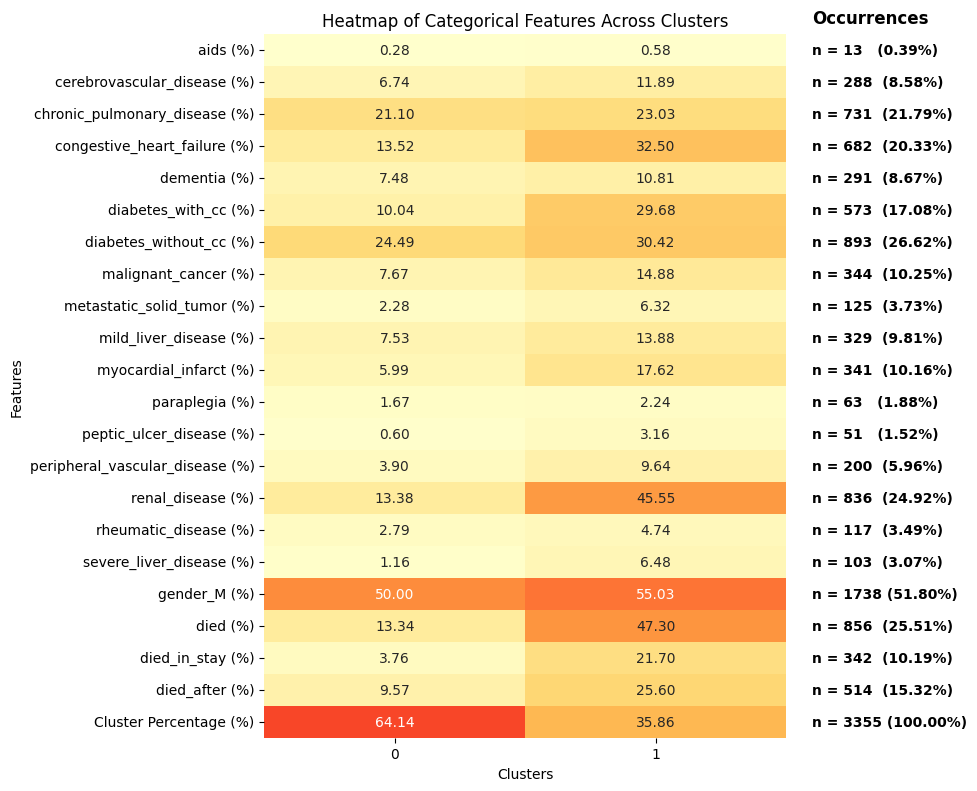

In [ ]:
helper.clustering(
    n_clusters=silhouette_param["n_clusters"],
    affinity=silhouette_param["affinity"],
    n_neighbors=silhouette_param.get("n_neighbors", 10),
    gamma=silhouette_param.get("gamma", 1e-3)
)
helper.heatmap_clusters_categorical(
    figsize=FIGSIZE_CLUSTER_HEATMAP,
    savepath=IMAGES_SAVE_PATH + "spectral-all-categorical",
)

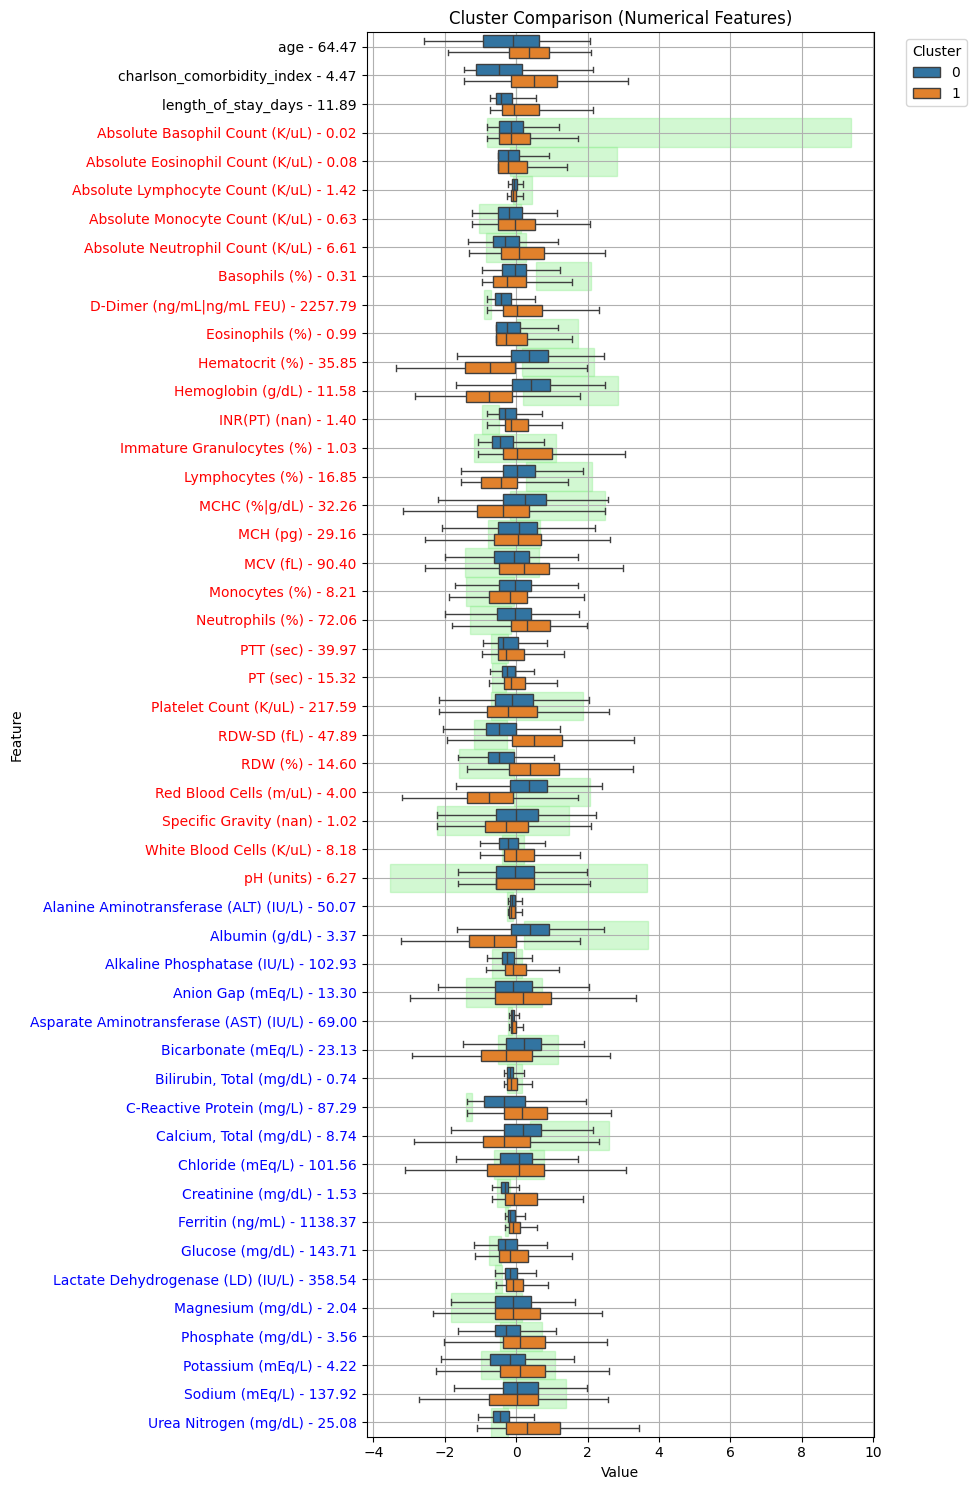

[]

In [ ]:
helper.show_cluster_compare_numerical(
    figsize=(10, 15),
    savepath=IMAGES_SAVE_PATH + "spectral-all-numerical",
)

In [ ]:
selected_clusters = [0, 1]

In [ ]:
helper.set_clustered_autoencoder()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:24<00:00,  4.03it/s]


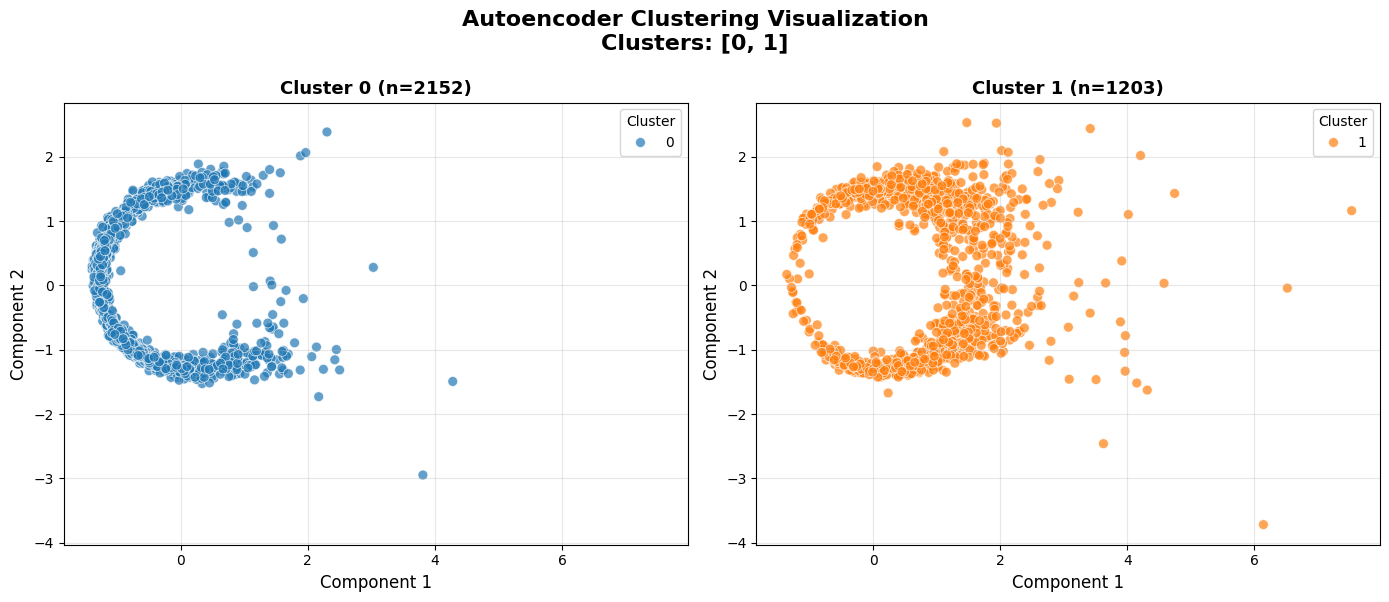

In [ ]:
helper.show_clustered_autoencoder(selected_clusters=selected_clusters, savepath=IMAGES_SAVE_PATH + "spectral-autoencoder-all")

##### Future Data

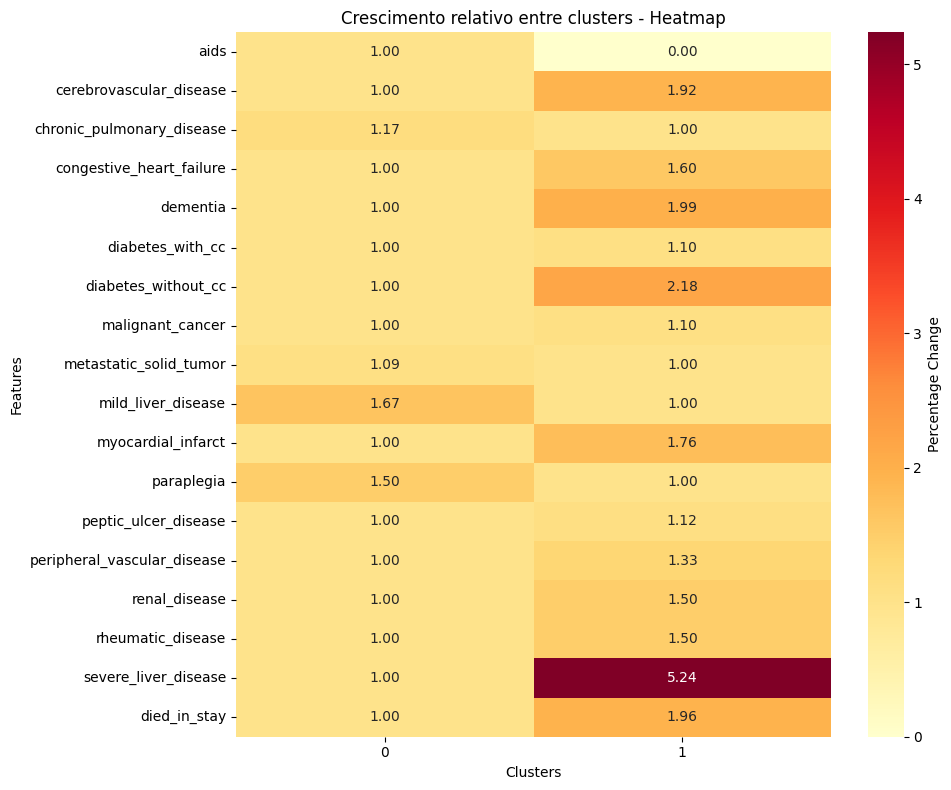

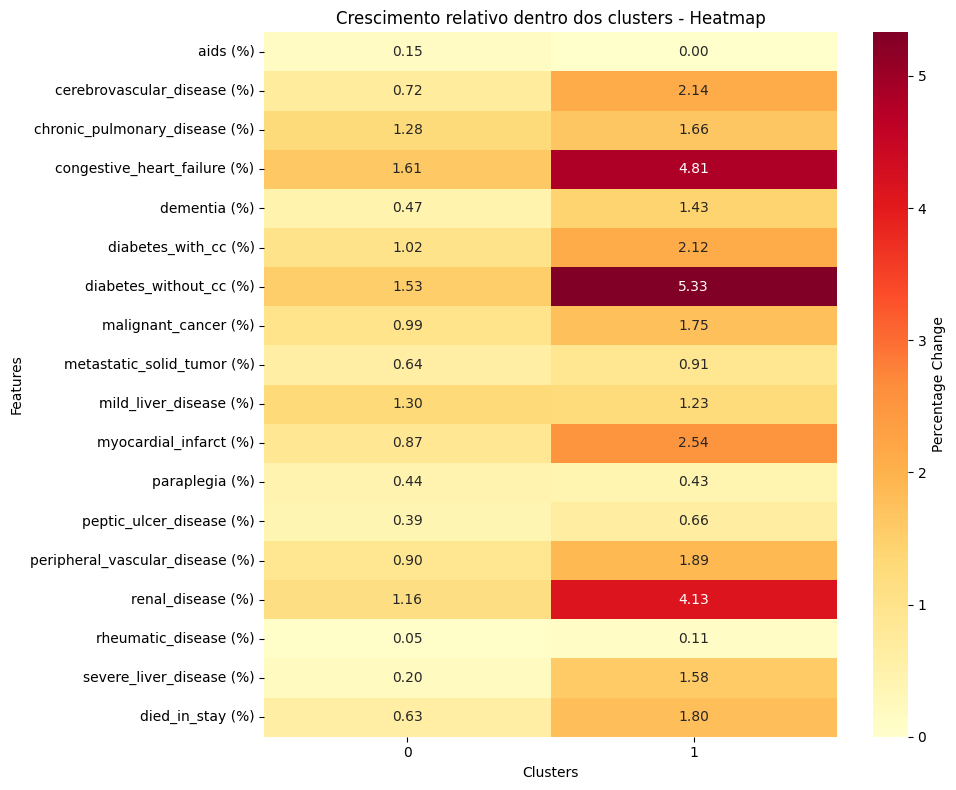

In [ ]:
future_helper = fa.FutureAnalysisHelper(
    helper.clustered_data, future_data, control, control_readmission
)
delta = future_helper.get_delta_clusters(percentage=True, relative_total=True)
future_helper.show_delta_heatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    relative_total=True,
    selected_clusters=selected_clusters,
    savepath=IMAGES_SAVE_PATH + "spectral-all-future",
)

In [ ]:
future_helper.get_mean_readmission()

{'Mean readmission Cluster 0': 2.13,
 'Mean readmission Cluster 1': 2.58,
 'Overall Mean readmission': 2.31}

In [ ]:
future_helper.get_mean_days_gap()

{'Mean days gap Cluster 0': 134.27,
 'Mean days gap Cluster 1': 117.33,
 'Overall Mean days gap': 127.49}

In [ ]:
future_helper.get_mortality_rates(onlyFirstAdmission=True)

{'Mortality rate Cluster 0': 0.16,
 'Mortality rate Cluster 1': 0.07,
 'Overall Mortality rate': 0.09}

# Add Log

In [29]:
log_file = "../log.csv"
current_dir = os.getcwd()
log_file_path = os.path.join(current_dir, log_file)

metrics = helper.getMetrics()

# Add line to save log
if os.path.exists(log_file_path):
    with open(log_file_path, 'a') as f:
        f.write(f"Spectral, None, Comprehensive, {metrics['disco']}, {metrics['dbcv']}, {metrics['dsi']}, {metrics['silhouette']}\n")